
## IPL Win Predictor

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

%matplotlib inline

In [2]:
match= pd.read_csv("Datasets/matches.csv")
delivery= pd.read_csv("Datasets/deliveries.csv")

In [3]:
match.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [4]:
delivery.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


In [5]:
match.shape

(756, 18)

In [6]:
delivery.shape

(150460, 21)

In [7]:
total_score_df=delivery.groupby(['match_id', 'inning']).sum()['total_runs'].reset_index()

In [8]:
total_score_df

,match_id,inning,total_runs
0,1,1,207
1,1,2,172
2,2,1,184
3,2,2,187
4,3,1,183
...,...,...,...
1279,634,2,140
1280,635,1,162
1281,635,2,163
1282,636,1,208


In [9]:
total_score_df=total_score_df[total_score_df['inning']==1]

In [10]:
total_score_df

,match_id,inning,total_runs
0,1,1,207
2,2,1,184
4,3,1,183
6,4,1,163
8,5,1,157
...,...,...,...
1274,632,1,138
1276,633,1,158
1278,634,1,162
1280,635,1,162


In [11]:
match.columns

Index(['id', 'season', 'city', 'date', 'team1', 'team2', 'toss_winner',
       'toss_decision', 'result', 'dl_applied', 'winner', 'win_by_runs',
       'win_by_wickets', 'player_of_match', 'venue', 'umpire1', 'umpire2',
       'umpire3'],
      dtype='object')

In [12]:
match.season.unique()

array([2017, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2018,
       2019])

In [13]:
match_df=match.merge(total_score_df[['match_id', 'total_runs']], left_on='id', right_on='match_id')

In [14]:
match_df

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3,match_id,total_runs
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN,1,207
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN,2,184
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN,3,183
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN,4,163
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN,5,157
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631,632,2016,Raipur,2016-05-22,Delhi Daredevils,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,6,V Kohli,Shaheed Veer Narayan Singh International Stadium,A Nand Kishore,BNJ Oxenford,NaN,632,138
632,633,2016,Bangalore,2016-05-24,Gujarat Lions,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,4,AB de Villiers,M Chinnaswamy Stadium,AK Chaudhary,HDPK Dharmasena,NaN,633,158
633,634,2016,Delhi,2016-05-25,Sunrisers Hyderabad,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Sunrisers Hyderabad,22,0,MC Henriques,Feroz Shah Kotla,M Erasmus,C Shamshuddin,NaN,634,162
634,635,2016,Delhi,2016-05-27,Gujarat Lions,Sunrisers Hyderabad,Sunrisers Hyderabad,field,normal,0,Sunrisers Hyderabad,0,4,DA Warner,Feroz Shah Kotla,M Erasmus,CK Nandan,NaN,635,162


In [15]:
match_df.team1.unique()

array(['Sunrisers Hyderabad', 'Mumbai Indians', 'Gujarat Lions',
       'Rising Pune Supergiant', 'Royal Challengers Bangalore',
       'Kolkata Knight Riders', 'Delhi Daredevils', 'Kings XI Punjab',
       'Chennai Super Kings', 'Rajasthan Royals', 'Deccan Chargers',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Rising Pune Supergiants'],
      dtype=object)

In [16]:
teams_to_remove=['Gujarat Lions', 'Rising Pune Supergiant', 'Kochi Tuskers Kerala', 'Pune Warriors', 'Rising Pune Supergiants']
match_df = match_df[
    (~match_df['team1'].isin(teams_to_remove)) &
    (~match_df['team2'].isin(teams_to_remove))]

In [17]:
match_df.team1= match_df.team1.str.replace('Delhi Daredevils', 'Delhi Capitals')
match_df.team1= match_df.team1.str.replace('Deccan Chargers', 'Sunrisers Hyderabad')
match_df.team2= match_df.team2.str.replace('Delhi Daredevils', 'Delhi Capitals')
match_df.team2= match_df.team2.str.replace('Deccan Chargers', 'Sunrisers Hyderabad')
match_df.winner= match_df.winner.str.replace('Delhi Daredevils', 'Delhi Capitals')
match_df.winner= match_df.winner.str.replace('Deccan Chargers', 'Sunrisers Hyderabad')

C:\Users\Guraa\AppData\Local\Temp\ipykernel_15936\1463122087.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  match_df.team1= match_df.team1.str.replace('Delhi Daredevils', 'Delhi Capitals')
C:\Users\Guraa\AppData\Local\Temp\ipykernel_15936\1463122087.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  match_df.team1= match_df.team1.str.replace('Deccan Chargers', 'Sunrisers Hyderabad')
C:\Users\Guraa\AppData\Local\Temp\ipykernel_15936\1463122087.py:3: SettingWithCopyWarning: 
A value is trying to be set 

In [18]:
match_df

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3,match_id,total_runs
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN,1,207
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Capitals,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN,5,157
6,7,2017,Mumbai,2017-04-09,Kolkata Knight Riders,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,4,N Rana,Wankhede Stadium,Nitin Menon,CK Nandan,NaN,7,178
7,8,2017,Indore,2017-04-10,Royal Challengers Bangalore,Kings XI Punjab,Royal Challengers Bangalore,bat,normal,0,Kings XI Punjab,0,8,AR Patel,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN,8,148
9,10,2017,Mumbai,2017-04-12,Sunrisers Hyderabad,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,4,JJ Bumrah,Wankhede Stadium,Nitin Menon,CK Nandan,NaN,10,158
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
627,628,2016,Raipur,2016-05-20,Sunrisers Hyderabad,Delhi Capitals,Delhi Daredevils,field,normal,0,Delhi Capitals,0,6,KK Nair,Shaheed Veer Narayan Singh International Stadium,A Nand Kishore,BNJ Oxenford,NaN,628,158
630,631,2016,Kolkata,2016-05-22,Kolkata Knight Riders,Sunrisers Hyderabad,Sunrisers Hyderabad,field,normal,0,Kolkata Knight Riders,22,0,YK Pathan,Eden Gardens,KN Ananthapadmanabhan,M Erasmus,NaN,631,171
631,632,2016,Raipur,2016-05-22,Delhi Capitals,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,6,V Kohli,Shaheed Veer Narayan Singh International Stadium,A Nand Kishore,BNJ Oxenford,NaN,632,138
633,634,2016,Delhi,2016-05-25,Sunrisers Hyderabad,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Sunrisers Hyderabad,22,0,MC Henriques,Feroz Shah Kotla,M Erasmus,C Shamshuddin,NaN,634,162


In [19]:
match_df.team1.unique()

array(['Sunrisers Hyderabad', 'Royal Challengers Bangalore',
       'Kolkata Knight Riders', 'Kings XI Punjab', 'Delhi Capitals',
       'Mumbai Indians', 'Chennai Super Kings', 'Rajasthan Royals'],
      dtype=object)

In [20]:
match_df.team1=match_df.team1.str.replace('Kings XI Punjab', 'Punjab Kings')
match_df.team2=match_df.team2.str.replace('Kings XI Punjab', 'Punjab Kings')
match_df.winner=match_df.winner.str.replace('Kings XI Punjab', 'Punjab Kings')

C:\Users\Guraa\AppData\Local\Temp\ipykernel_15936\3207900973.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  match_df.team1=match_df.team1.str.replace('Kings XI Punjab', 'Punjab Kings')
C:\Users\Guraa\AppData\Local\Temp\ipykernel_15936\3207900973.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  match_df.team2=match_df.team2.str.replace('Kings XI Punjab', 'Punjab Kings')
C:\Users\Guraa\AppData\Local\Temp\ipykernel_15936\3207900973.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of

In [21]:
match_df.team1.unique()

array(['Sunrisers Hyderabad', 'Royal Challengers Bangalore',
       'Kolkata Knight Riders', 'Punjab Kings', 'Delhi Capitals',
       'Mumbai Indians', 'Chennai Super Kings', 'Rajasthan Royals'],
      dtype=object)

In [22]:
match_df.team2.unique()

array(['Royal Challengers Bangalore', 'Delhi Capitals', 'Mumbai Indians',
       'Punjab Kings', 'Kolkata Knight Riders', 'Sunrisers Hyderabad',
       'Rajasthan Royals', 'Chennai Super Kings'], dtype=object)

In [23]:
match_df.shape

(521, 20)

In [24]:
match_df.winner.value_counts()

winner
Mumbai Indians                 83
Chennai Super Kings            74
Kolkata Knight Riders          69
Punjab Kings                   62
Royal Challengers Bangalore    61
Sunrisers Hyderabad            59
Rajasthan Royals               58
Delhi Capitals                 53
Name: count, dtype: int64

In [25]:
match_df=match_df[match_df.dl_applied==0]

In [26]:
match_df.dl_applied.value_counts()

dl_applied
0    509
Name: count, dtype: int64

In [27]:
match_df

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3,match_id,total_runs
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN,1,207
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Capitals,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN,5,157
6,7,2017,Mumbai,2017-04-09,Kolkata Knight Riders,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,4,N Rana,Wankhede Stadium,Nitin Menon,CK Nandan,NaN,7,178
7,8,2017,Indore,2017-04-10,Royal Challengers Bangalore,Punjab Kings,Royal Challengers Bangalore,bat,normal,0,Punjab Kings,0,8,AR Patel,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN,8,148
9,10,2017,Mumbai,2017-04-12,Sunrisers Hyderabad,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,4,JJ Bumrah,Wankhede Stadium,Nitin Menon,CK Nandan,NaN,10,158
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
627,628,2016,Raipur,2016-05-20,Sunrisers Hyderabad,Delhi Capitals,Delhi Daredevils,field,normal,0,Delhi Capitals,0,6,KK Nair,Shaheed Veer Narayan Singh International Stadium,A Nand Kishore,BNJ Oxenford,NaN,628,158
630,631,2016,Kolkata,2016-05-22,Kolkata Knight Riders,Sunrisers Hyderabad,Sunrisers Hyderabad,field,normal,0,Kolkata Knight Riders,22,0,YK Pathan,Eden Gardens,KN Ananthapadmanabhan,M Erasmus,NaN,631,171
631,632,2016,Raipur,2016-05-22,Delhi Capitals,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,6,V Kohli,Shaheed Veer Narayan Singh International Stadium,A Nand Kishore,BNJ Oxenford,NaN,632,138
633,634,2016,Delhi,2016-05-25,Sunrisers Hyderabad,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Sunrisers Hyderabad,22,0,MC Henriques,Feroz Shah Kotla,M Erasmus,C Shamshuddin,NaN,634,162


In [28]:
match_df=match_df[['match_id', 'city', 'winner', 'total_runs']]

In [29]:
match_df

,match_id,city,winner,total_runs
0,1,Hyderabad,Sunrisers Hyderabad,207
4,5,Bangalore,Royal Challengers Bangalore,157
6,7,Mumbai,Mumbai Indians,178
7,8,Indore,Punjab Kings,148
9,10,Mumbai,Mumbai Indians,158
...,...,...,...,...
627,628,Raipur,Delhi Capitals,158
630,631,Kolkata,Kolkata Knight Riders,171
631,632,Raipur,Royal Challengers Bangalore,138
633,634,Delhi,Sunrisers Hyderabad,162


In [30]:
delivery_df=match_df.merge(delivery, on='match_id')
delivery_df

,match_id,city,winner,total_runs_x,inning,batting_team,bowling_team,over,ball,batsman,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs_y,player_dismissed,dismissal_kind,fielder
0,1,Hyderabad,Sunrisers Hyderabad,207,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,Hyderabad,Sunrisers Hyderabad,207,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,Hyderabad,Sunrisers Hyderabad,207,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,Hyderabad,Sunrisers Hyderabad,207,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,Hyderabad,Sunrisers Hyderabad,207,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,...,0,0,0,0,0,2,2,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121482,636,Bangalore,Sunrisers Hyderabad,208,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,2,Sachin Baby,...,0,0,0,0,2,0,2,NaN,NaN,NaN
121483,636,Bangalore,Sunrisers Hyderabad,208,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,3,Sachin Baby,...,0,0,0,0,0,0,0,CJ Jordan,run out,NV Ojha
121484,636,Bangalore,Sunrisers Hyderabad,208,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,4,Iqbal Abdulla,...,0,1,0,0,0,1,1,NaN,NaN,NaN
121485,636,Bangalore,Sunrisers Hyderabad,208,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,5,Sachin Baby,...,0,0,0,0,1,0,1,NaN,NaN,NaN


In [31]:
delivery_df.columns

Index(['match_id', 'city', 'winner', 'total_runs_x', 'inning', 'batting_team',
       'bowling_team', 'over', 'ball', 'batsman', 'non_striker', 'bowler',
       'is_super_over', 'wide_runs', 'bye_runs', 'legbye_runs', 'noball_runs',
       'penalty_runs', 'batsman_runs', 'extra_runs', 'total_runs_y',
       'player_dismissed', 'dismissal_kind', 'fielder'],
      dtype='object')

In [32]:
delivery_df=delivery_df[~(delivery_df.bowling_team.isin(teams_to_remove))&
                        ~(delivery_df.batting_team.isin(teams_to_remove))]

In [33]:
delivery_df.bowling_team.unique()

array(['Royal Challengers Bangalore', 'Sunrisers Hyderabad',
       'Delhi Daredevils', 'Mumbai Indians', 'Kolkata Knight Riders',
       'Kings XI Punjab', 'Chennai Super Kings', 'Rajasthan Royals',
       'Deccan Chargers'], dtype=object)

In [34]:
delivery_df.bowling_team= delivery_df.bowling_team.str.replace('Delhi Daredevils', 'Delhi Capitals')
delivery_df.bowling_team= delivery_df.bowling_team.str.replace('Deccan Chargers', 'Sunrisers Hyderabad')
delivery_df.batting_team= delivery_df.batting_team.str.replace('Delhi Daredevils', 'Delhi Capitals')
delivery_df.batting_team= delivery_df.batting_team.str.replace('Deccan Chargers', 'Sunrisers Hyderabad')
delivery_df.bowling_team= delivery_df.bowling_team.str.replace('Kings XI Punjab', 'Punjab Kings')
delivery_df.batting_team= delivery_df.batting_team.str.replace('Kings XI Punjab', 'Punjab Kings')

In [35]:
delivery_df

,match_id,city,winner,total_runs_x,inning,batting_team,bowling_team,over,ball,batsman,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs_y,player_dismissed,dismissal_kind,fielder
0,1,Hyderabad,Sunrisers Hyderabad,207,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,Hyderabad,Sunrisers Hyderabad,207,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,Hyderabad,Sunrisers Hyderabad,207,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,Hyderabad,Sunrisers Hyderabad,207,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,Hyderabad,Sunrisers Hyderabad,207,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,...,0,0,0,0,0,2,2,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121482,636,Bangalore,Sunrisers Hyderabad,208,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,2,Sachin Baby,...,0,0,0,0,2,0,2,NaN,NaN,NaN
121483,636,Bangalore,Sunrisers Hyderabad,208,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,3,Sachin Baby,...,0,0,0,0,0,0,0,CJ Jordan,run out,NV Ojha
121484,636,Bangalore,Sunrisers Hyderabad,208,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,4,Iqbal Abdulla,...,0,1,0,0,0,1,1,NaN,NaN,NaN
121485,636,Bangalore,Sunrisers Hyderabad,208,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,5,Sachin Baby,...,0,0,0,0,1,0,1,NaN,NaN,NaN


In [36]:
delivery_df=delivery_df[delivery_df['inning']==2]

In [37]:
delivery_df

,match_id,city,winner,total_runs_x,inning,batting_team,bowling_team,over,ball,batsman,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs_y,player_dismissed,dismissal_kind,fielder
125,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,1,CH Gayle,...,0,0,0,0,1,0,1,NaN,NaN,NaN
126,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,2,Mandeep Singh,...,0,0,0,0,0,0,0,NaN,NaN,NaN
127,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,3,Mandeep Singh,...,0,0,0,0,0,0,0,NaN,NaN,NaN
128,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,4,Mandeep Singh,...,0,0,0,0,2,0,2,NaN,NaN,NaN
129,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,5,Mandeep Singh,...,0,0,0,0,4,0,4,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121482,636,Bangalore,Sunrisers Hyderabad,208,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,2,Sachin Baby,...,0,0,0,0,2,0,2,NaN,NaN,NaN
121483,636,Bangalore,Sunrisers Hyderabad,208,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,3,Sachin Baby,...,0,0,0,0,0,0,0,CJ Jordan,run out,NV Ojha
121484,636,Bangalore,Sunrisers Hyderabad,208,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,4,Iqbal Abdulla,...,0,1,0,0,0,1,1,NaN,NaN,NaN
121485,636,Bangalore,Sunrisers Hyderabad,208,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,5,Sachin Baby,...,0,0,0,0,1,0,1,NaN,NaN,NaN


In [38]:
delivery_df.shape

(58704, 24)

In [39]:
delivery_df['current_score']=delivery_df.groupby('match_id').total_runs_y.cumsum()
delivery_df

C:\Users\Guraa\AppData\Local\Temp\ipykernel_15936\623311506.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivery_df['current_score']=delivery_df.groupby('match_id').total_runs_y.cumsum()


,match_id,city,winner,total_runs_x,inning,batting_team,bowling_team,over,ball,batsman,...,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs_y,player_dismissed,dismissal_kind,fielder,current_score
125,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,1,CH Gayle,...,0,0,0,1,0,1,NaN,NaN,NaN,1
126,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,2,Mandeep Singh,...,0,0,0,0,0,0,NaN,NaN,NaN,1
127,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,3,Mandeep Singh,...,0,0,0,0,0,0,NaN,NaN,NaN,1
128,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,4,Mandeep Singh,...,0,0,0,2,0,2,NaN,NaN,NaN,3
129,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,5,Mandeep Singh,...,0,0,0,4,0,4,NaN,NaN,NaN,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121482,636,Bangalore,Sunrisers Hyderabad,208,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,2,Sachin Baby,...,0,0,0,2,0,2,NaN,NaN,NaN,194
121483,636,Bangalore,Sunrisers Hyderabad,208,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,3,Sachin Baby,...,0,0,0,0,0,0,CJ Jordan,run out,NV Ojha,194
121484,636,Bangalore,Sunrisers Hyderabad,208,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,4,Iqbal Abdulla,...,1,0,0,0,1,1,NaN,NaN,NaN,195
121485,636,Bangalore,Sunrisers Hyderabad,208,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,5,Sachin Baby,...,0,0,0,1,0,1,NaN,NaN,NaN,196


In [40]:
delivery_df['target']=delivery_df.total_runs_x+1

C:\Users\Guraa\AppData\Local\Temp\ipykernel_15936\4000015300.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivery_df['target']=delivery_df.total_runs_x+1


In [41]:
delivery_df['runs_left']=delivery_df.target-delivery_df.current_score
delivery_df

C:\Users\Guraa\AppData\Local\Temp\ipykernel_15936\3967293740.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivery_df['runs_left']=delivery_df.target-delivery_df.current_score


,match_id,city,winner,total_runs_x,inning,batting_team,bowling_team,over,ball,batsman,...,penalty_runs,batsman_runs,extra_runs,total_runs_y,player_dismissed,dismissal_kind,fielder,current_score,target,runs_left
125,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,1,CH Gayle,...,0,1,0,1,NaN,NaN,NaN,1,208,207
126,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,2,Mandeep Singh,...,0,0,0,0,NaN,NaN,NaN,1,208,207
127,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,3,Mandeep Singh,...,0,0,0,0,NaN,NaN,NaN,1,208,207
128,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,4,Mandeep Singh,...,0,2,0,2,NaN,NaN,NaN,3,208,205
129,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,5,Mandeep Singh,...,0,4,0,4,NaN,NaN,NaN,7,208,201
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121482,636,Bangalore,Sunrisers Hyderabad,208,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,2,Sachin Baby,...,0,2,0,2,NaN,NaN,NaN,194,209,15
121483,636,Bangalore,Sunrisers Hyderabad,208,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,3,Sachin Baby,...,0,0,0,0,CJ Jordan,run out,NV Ojha,194,209,15
121484,636,Bangalore,Sunrisers Hyderabad,208,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,4,Iqbal Abdulla,...,0,0,1,1,NaN,NaN,NaN,195,209,14
121485,636,Bangalore,Sunrisers Hyderabad,208,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,5,Sachin Baby,...,0,1,0,1,NaN,NaN,NaN,196,209,13


In [42]:
delivery_df.drop('total_runs_x', axis=1, inplace=True)

C:\Users\Guraa\AppData\Local\Temp\ipykernel_15936\361340121.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivery_df.drop('total_runs_x', axis=1, inplace=True)


In [43]:
delivery_df.columns

Index(['match_id', 'city', 'winner', 'inning', 'batting_team', 'bowling_team',
       'over', 'ball', 'batsman', 'non_striker', 'bowler', 'is_super_over',
       'wide_runs', 'bye_runs', 'legbye_runs', 'noball_runs', 'penalty_runs',
       'batsman_runs', 'extra_runs', 'total_runs_y', 'player_dismissed',
       'dismissal_kind', 'fielder', 'current_score', 'target', 'runs_left'],
      dtype='object')

In [44]:
delivery_df['balls_left']=126-(delivery_df.over*6 + delivery_df.ball)
delivery_df

C:\Users\Guraa\AppData\Local\Temp\ipykernel_15936\1849960732.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivery_df['balls_left']=126-(delivery_df.over*6 + delivery_df.ball)


,match_id,city,winner,inning,batting_team,bowling_team,over,ball,batsman,non_striker,...,batsman_runs,extra_runs,total_runs_y,player_dismissed,dismissal_kind,fielder,current_score,target,runs_left,balls_left
125,1,Hyderabad,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,1,CH Gayle,Mandeep Singh,...,1,0,1,NaN,NaN,NaN,1,208,207,119
126,1,Hyderabad,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,2,Mandeep Singh,CH Gayle,...,0,0,0,NaN,NaN,NaN,1,208,207,118
127,1,Hyderabad,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,3,Mandeep Singh,CH Gayle,...,0,0,0,NaN,NaN,NaN,1,208,207,117
128,1,Hyderabad,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,4,Mandeep Singh,CH Gayle,...,2,0,2,NaN,NaN,NaN,3,208,205,116
129,1,Hyderabad,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,5,Mandeep Singh,CH Gayle,...,4,0,4,NaN,NaN,NaN,7,208,201,115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121482,636,Bangalore,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,2,Sachin Baby,CJ Jordan,...,2,0,2,NaN,NaN,NaN,194,209,15,4
121483,636,Bangalore,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,3,Sachin Baby,CJ Jordan,...,0,0,0,CJ Jordan,run out,NV Ojha,194,209,15,3
121484,636,Bangalore,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,4,Iqbal Abdulla,Sachin Baby,...,0,1,1,NaN,NaN,NaN,195,209,14,2
121485,636,Bangalore,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,5,Sachin Baby,Iqbal Abdulla,...,1,0,1,NaN,NaN,NaN,196,209,13,1


In [45]:
delivery_df.player_dismissed.value_counts()

player_dismissed
G Gambhir        62
RG Sharma        56
V Kohli          51
RV Uthappa       49
V Sehwag         48
                 ..
B Laughlin        1
VR Aaron          1
KW Richardson     1
R Shukla          1
CJ Jordan         1
Name: count, Length: 353, dtype: int64

In [46]:
delivery_df['player_dismissed'] = delivery_df['player_dismissed'].notnull().astype(int)

C:\Users\Guraa\AppData\Local\Temp\ipykernel_15936\142422167.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivery_df['player_dismissed'] = delivery_df['player_dismissed'].notnull().astype(int)


In [47]:
delivery_df.player_dismissed.value_counts()

player_dismissed
0    55802
1     2902
Name: count, dtype: int64

In [48]:
delivery_df

,match_id,city,winner,inning,batting_team,bowling_team,over,ball,batsman,non_striker,...,batsman_runs,extra_runs,total_runs_y,player_dismissed,dismissal_kind,fielder,current_score,target,runs_left,balls_left
125,1,Hyderabad,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,1,CH Gayle,Mandeep Singh,...,1,0,1,0,NaN,NaN,1,208,207,119
126,1,Hyderabad,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,2,Mandeep Singh,CH Gayle,...,0,0,0,0,NaN,NaN,1,208,207,118
127,1,Hyderabad,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,3,Mandeep Singh,CH Gayle,...,0,0,0,0,NaN,NaN,1,208,207,117
128,1,Hyderabad,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,4,Mandeep Singh,CH Gayle,...,2,0,2,0,NaN,NaN,3,208,205,116
129,1,Hyderabad,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,5,Mandeep Singh,CH Gayle,...,4,0,4,0,NaN,NaN,7,208,201,115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121482,636,Bangalore,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,2,Sachin Baby,CJ Jordan,...,2,0,2,0,NaN,NaN,194,209,15,4
121483,636,Bangalore,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,3,Sachin Baby,CJ Jordan,...,0,0,0,1,run out,NV Ojha,194,209,15,3
121484,636,Bangalore,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,4,Iqbal Abdulla,Sachin Baby,...,0,1,1,0,NaN,NaN,195,209,14,2
121485,636,Bangalore,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,5,Sachin Baby,Iqbal Abdulla,...,1,0,1,0,NaN,NaN,196,209,13,1


In [49]:
wickets=delivery_df.groupby('match_id')['player_dismissed'].cumsum()
delivery_df['wickets_left']=10-wickets
delivery_df

C:\Users\Guraa\AppData\Local\Temp\ipykernel_15936\3905582080.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivery_df['wickets_left']=10-wickets


,match_id,city,winner,inning,batting_team,bowling_team,over,ball,batsman,non_striker,...,extra_runs,total_runs_y,player_dismissed,dismissal_kind,fielder,current_score,target,runs_left,balls_left,wickets_left
125,1,Hyderabad,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,1,CH Gayle,Mandeep Singh,...,0,1,0,NaN,NaN,1,208,207,119,10
126,1,Hyderabad,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,2,Mandeep Singh,CH Gayle,...,0,0,0,NaN,NaN,1,208,207,118,10
127,1,Hyderabad,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,3,Mandeep Singh,CH Gayle,...,0,0,0,NaN,NaN,1,208,207,117,10
128,1,Hyderabad,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,4,Mandeep Singh,CH Gayle,...,0,2,0,NaN,NaN,3,208,205,116,10
129,1,Hyderabad,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,5,Mandeep Singh,CH Gayle,...,0,4,0,NaN,NaN,7,208,201,115,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121482,636,Bangalore,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,2,Sachin Baby,CJ Jordan,...,0,2,0,NaN,NaN,194,209,15,4,4
121483,636,Bangalore,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,3,Sachin Baby,CJ Jordan,...,0,0,1,run out,NV Ojha,194,209,15,3,3
121484,636,Bangalore,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,4,Iqbal Abdulla,Sachin Baby,...,1,1,0,NaN,NaN,195,209,14,2,3
121485,636,Bangalore,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,5,Sachin Baby,Iqbal Abdulla,...,0,1,0,NaN,NaN,196,209,13,1,3


In [50]:
delivery_df.sample(10)

,match_id,city,winner,inning,batting_team,bowling_team,over,ball,batsman,non_striker,...,extra_runs,total_runs_y,player_dismissed,dismissal_kind,fielder,current_score,target,runs_left,balls_left,wickets_left
120422,628,Raipur,Delhi Capitals,2,Delhi Capitals,Sunrisers Hyderabad,6,5,KK Nair,RR Pant,...,0,0,0,NaN,NaN,37,159,122,85,9
53497,273,Mumbai,Mumbai Indians,2,Punjab Kings,Mumbai Indians,7,1,PC Valthaty,SE Marsh,...,0,1,0,NaN,NaN,25,160,135,83,9
27656,151,Kimberley,Punjab Kings,2,Punjab Kings,Sunrisers Hyderabad,12,3,IK Pathan,DPMD Jayawardene,...,0,1,0,NaN,NaN,98,169,71,51,6
28829,156,Centurion,Royal Challengers Bangalore,2,Royal Challengers Bangalore,Kolkata Knight Riders,5,3,JH Kallis,JD Ryder,...,0,0,0,NaN,NaN,28,174,146,93,10
57276,303,Kolkata,Mumbai Indians,2,Mumbai Indians,Kolkata Knight Riders,1,2,TL Suman,SR Tendulkar,...,0,0,0,NaN,NaN,4,176,172,118,10
9822,71,Chennai,Chennai Super Kings,2,Chennai Super Kings,Kolkata Knight Riders,8,4,ML Hayden,PA Patel,...,0,0,0,NaN,NaN,63,148,85,74,10
65265,345,Delhi,Delhi Capitals,2,Rajasthan Royals,Delhi Capitals,18,6,AM Rahane,BJ Hodge,...,0,1,0,NaN,NaN,138,153,15,12,9
91083,476,Abu Dhabi,Rajasthan Royals,2,Kolkata Knight Riders,Rajasthan Royals,20,7,Shakib Al Hasan,SP Narine,...,0,2,0,NaN,NaN,152,153,1,-1,2
6230,50,Mumbai,Punjab Kings,2,Mumbai Indians,Punjab Kings,4,2,PA Patel,LMP Simmons,...,0,0,0,NaN,NaN,30,231,201,100,10
80504,425,Chennai,Chennai Super Kings,2,Punjab Kings,Chennai Super Kings,18,4,SE Marsh,DA Miller,...,0,2,0,NaN,NaN,150,187,37,14,7


In [51]:
delivery_df['bowls_bowled']= 120-delivery_df['balls_left']
delivery_df

C:\Users\Guraa\AppData\Local\Temp\ipykernel_15936\539918251.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivery_df['bowls_bowled']= 120-delivery_df['balls_left']


,match_id,city,winner,inning,batting_team,bowling_team,over,ball,batsman,non_striker,...,total_runs_y,player_dismissed,dismissal_kind,fielder,current_score,target,runs_left,balls_left,wickets_left,bowls_bowled
125,1,Hyderabad,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,1,CH Gayle,Mandeep Singh,...,1,0,NaN,NaN,1,208,207,119,10,1
126,1,Hyderabad,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,2,Mandeep Singh,CH Gayle,...,0,0,NaN,NaN,1,208,207,118,10,2
127,1,Hyderabad,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,3,Mandeep Singh,CH Gayle,...,0,0,NaN,NaN,1,208,207,117,10,3
128,1,Hyderabad,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,4,Mandeep Singh,CH Gayle,...,2,0,NaN,NaN,3,208,205,116,10,4
129,1,Hyderabad,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,5,Mandeep Singh,CH Gayle,...,4,0,NaN,NaN,7,208,201,115,10,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121482,636,Bangalore,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,2,Sachin Baby,CJ Jordan,...,2,0,NaN,NaN,194,209,15,4,4,116
121483,636,Bangalore,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,3,Sachin Baby,CJ Jordan,...,0,1,run out,NV Ojha,194,209,15,3,3,117
121484,636,Bangalore,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,4,Iqbal Abdulla,Sachin Baby,...,1,0,NaN,NaN,195,209,14,2,3,118
121485,636,Bangalore,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,5,Sachin Baby,Iqbal Abdulla,...,1,0,NaN,NaN,196,209,13,1,3,119


In [52]:
delivery_df['current_run_rate']=(delivery_df['current_score']/(delivery_df['bowls_bowled']/6)).round(2)
delivery_df

C:\Users\Guraa\AppData\Local\Temp\ipykernel_15936\3631060471.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivery_df['current_run_rate']=(delivery_df['current_score']/(delivery_df['bowls_bowled']/6)).round(2)


,match_id,city,winner,inning,batting_team,bowling_team,over,ball,batsman,non_striker,...,player_dismissed,dismissal_kind,fielder,current_score,target,runs_left,balls_left,wickets_left,bowls_bowled,current_run_rate
125,1,Hyderabad,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,1,CH Gayle,Mandeep Singh,...,0,NaN,NaN,1,208,207,119,10,1,6.00
126,1,Hyderabad,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,2,Mandeep Singh,CH Gayle,...,0,NaN,NaN,1,208,207,118,10,2,3.00
127,1,Hyderabad,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,3,Mandeep Singh,CH Gayle,...,0,NaN,NaN,1,208,207,117,10,3,2.00
128,1,Hyderabad,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,4,Mandeep Singh,CH Gayle,...,0,NaN,NaN,3,208,205,116,10,4,4.50
129,1,Hyderabad,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,5,Mandeep Singh,CH Gayle,...,0,NaN,NaN,7,208,201,115,10,5,8.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121482,636,Bangalore,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,2,Sachin Baby,CJ Jordan,...,0,NaN,NaN,194,209,15,4,4,116,10.03
121483,636,Bangalore,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,3,Sachin Baby,CJ Jordan,...,1,run out,NV Ojha,194,209,15,3,3,117,9.95
121484,636,Bangalore,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,4,Iqbal Abdulla,Sachin Baby,...,0,NaN,NaN,195,209,14,2,3,118,9.92
121485,636,Bangalore,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,5,Sachin Baby,Iqbal Abdulla,...,0,NaN,NaN,196,209,13,1,3,119,9.88


In [53]:
delivery_df['required_run_rate']=(delivery_df['runs_left']/(delivery_df['balls_left']/6)).round(2)
delivery_df

C:\Users\Guraa\AppData\Local\Temp\ipykernel_15936\2356180882.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivery_df['required_run_rate']=(delivery_df['runs_left']/(delivery_df['balls_left']/6)).round(2)


,match_id,city,winner,inning,batting_team,bowling_team,over,ball,batsman,non_striker,...,dismissal_kind,fielder,current_score,target,runs_left,balls_left,wickets_left,bowls_bowled,current_run_rate,required_run_rate
125,1,Hyderabad,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,1,CH Gayle,Mandeep Singh,...,NaN,NaN,1,208,207,119,10,1,6.00,10.44
126,1,Hyderabad,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,2,Mandeep Singh,CH Gayle,...,NaN,NaN,1,208,207,118,10,2,3.00,10.53
127,1,Hyderabad,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,3,Mandeep Singh,CH Gayle,...,NaN,NaN,1,208,207,117,10,3,2.00,10.62
128,1,Hyderabad,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,4,Mandeep Singh,CH Gayle,...,NaN,NaN,3,208,205,116,10,4,4.50,10.60
129,1,Hyderabad,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,5,Mandeep Singh,CH Gayle,...,NaN,NaN,7,208,201,115,10,5,8.40,10.49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121482,636,Bangalore,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,2,Sachin Baby,CJ Jordan,...,NaN,NaN,194,209,15,4,4,116,10.03,22.50
121483,636,Bangalore,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,3,Sachin Baby,CJ Jordan,...,run out,NV Ojha,194,209,15,3,3,117,9.95,30.00
121484,636,Bangalore,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,4,Iqbal Abdulla,Sachin Baby,...,NaN,NaN,195,209,14,2,3,118,9.92,42.00
121485,636,Bangalore,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,5,Sachin Baby,Iqbal Abdulla,...,NaN,NaN,196,209,13,1,3,119,9.88,78.00


In [54]:
delivery_df.drop('bowls_bowled', inplace=True,axis=1)

C:\Users\Guraa\AppData\Local\Temp\ipykernel_15936\3888006735.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivery_df.drop('bowls_bowled', inplace=True,axis=1)


In [55]:
delivery_df

,match_id,city,winner,inning,batting_team,bowling_team,over,ball,batsman,non_striker,...,player_dismissed,dismissal_kind,fielder,current_score,target,runs_left,balls_left,wickets_left,current_run_rate,required_run_rate
125,1,Hyderabad,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,1,CH Gayle,Mandeep Singh,...,0,NaN,NaN,1,208,207,119,10,6.00,10.44
126,1,Hyderabad,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,2,Mandeep Singh,CH Gayle,...,0,NaN,NaN,1,208,207,118,10,3.00,10.53
127,1,Hyderabad,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,3,Mandeep Singh,CH Gayle,...,0,NaN,NaN,1,208,207,117,10,2.00,10.62
128,1,Hyderabad,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,4,Mandeep Singh,CH Gayle,...,0,NaN,NaN,3,208,205,116,10,4.50,10.60
129,1,Hyderabad,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,5,Mandeep Singh,CH Gayle,...,0,NaN,NaN,7,208,201,115,10,8.40,10.49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121482,636,Bangalore,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,2,Sachin Baby,CJ Jordan,...,0,NaN,NaN,194,209,15,4,4,10.03,22.50
121483,636,Bangalore,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,3,Sachin Baby,CJ Jordan,...,1,run out,NV Ojha,194,209,15,3,3,9.95,30.00
121484,636,Bangalore,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,4,Iqbal Abdulla,Sachin Baby,...,0,NaN,NaN,195,209,14,2,3,9.92,42.00
121485,636,Bangalore,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,5,Sachin Baby,Iqbal Abdulla,...,0,NaN,NaN,196,209,13,1,3,9.88,78.00


In [56]:
def result(row):
    if row['batting_team']==row['winner']:
        return 1
    else:
        return 0
delivery_df['result']=delivery_df.apply(result, axis=1)
delivery_df

C:\Users\Guraa\AppData\Local\Temp\ipykernel_15936\1749556128.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivery_df['result']=delivery_df.apply(result, axis=1)


,match_id,city,winner,inning,batting_team,bowling_team,over,ball,batsman,non_striker,...,dismissal_kind,fielder,current_score,target,runs_left,balls_left,wickets_left,current_run_rate,required_run_rate,result
125,1,Hyderabad,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,1,CH Gayle,Mandeep Singh,...,NaN,NaN,1,208,207,119,10,6.00,10.44,0
126,1,Hyderabad,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,2,Mandeep Singh,CH Gayle,...,NaN,NaN,1,208,207,118,10,3.00,10.53,0
127,1,Hyderabad,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,3,Mandeep Singh,CH Gayle,...,NaN,NaN,1,208,207,117,10,2.00,10.62,0
128,1,Hyderabad,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,4,Mandeep Singh,CH Gayle,...,NaN,NaN,3,208,205,116,10,4.50,10.60,0
129,1,Hyderabad,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,5,Mandeep Singh,CH Gayle,...,NaN,NaN,7,208,201,115,10,8.40,10.49,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121482,636,Bangalore,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,2,Sachin Baby,CJ Jordan,...,NaN,NaN,194,209,15,4,4,10.03,22.50,0
121483,636,Bangalore,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,3,Sachin Baby,CJ Jordan,...,run out,NV Ojha,194,209,15,3,3,9.95,30.00,0
121484,636,Bangalore,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,4,Iqbal Abdulla,Sachin Baby,...,NaN,NaN,195,209,14,2,3,9.92,42.00,0
121485,636,Bangalore,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,5,Sachin Baby,Iqbal Abdulla,...,NaN,NaN,196,209,13,1,3,9.88,78.00,0


In [57]:
delivery_df.columns

Index(['match_id', 'city', 'winner', 'inning', 'batting_team', 'bowling_team',
       'over', 'ball', 'batsman', 'non_striker', 'bowler', 'is_super_over',
       'wide_runs', 'bye_runs', 'legbye_runs', 'noball_runs', 'penalty_runs',
       'batsman_runs', 'extra_runs', 'total_runs_y', 'player_dismissed',
       'dismissal_kind', 'fielder', 'current_score', 'target', 'runs_left',
       'balls_left', 'wickets_left', 'current_run_rate', 'required_run_rate',
       'result'],
      dtype='object')

In [58]:
final_df=delivery_df[['batting_team', 'bowling_team', 'city', 'runs_left', 'balls_left', 'wickets_left', 'target', 'current_score', 'current_run_rate', 'required_run_rate', 'result']]
final_df.sample(10)

,batting_team,bowling_team,city,runs_left,balls_left,wickets_left,target,current_score,current_run_rate,required_run_rate,result
107240,Delhi Capitals,Kolkata Knight Riders,Kolkata,77,42,8,172,95,7.31,11.00,0
58291,Royal Challengers Bangalore,Chennai Super Kings,Chennai,176,92,8,206,30,6.43,11.48,0
15428,Delhi Capitals,Kolkata Knight Riders,Kolkata,97,85,6,134,37,6.34,6.85,0
3758,Kolkata Knight Riders,Delhi Capitals,Kolkata,59,58,9,161,102,9.87,6.10,1
40798,Royal Challengers Bangalore,Punjab Kings,Chandigarh,116,69,8,182,66,7.76,10.09,1
44966,Chennai Super Kings,Kolkata Knight Riders,Chennai,14,49,9,140,126,10.65,1.71,1
20388,Chennai Super Kings,Mumbai Indians,Cape Town,128,86,8,166,38,6.71,8.93,0
22043,Punjab Kings,Royal Challengers Bangalore,Durban,117,80,9,169,52,7.80,8.78,1
104566,Rajasthan Royals,Chennai Super Kings,Ahmedabad,103,75,10,157,54,7.20,8.24,1
19245,Rajasthan Royals,Mumbai Indians,Jaipur,68,47,5,146,78,6.41,8.68,1


In [59]:
#Shuffle the dataset so that there is no buystness in the order of matches
final_df=final_df.sample(final_df.shape[0])
final_df

,batting_team,bowling_team,city,runs_left,balls_left,wickets_left,target,current_score,current_run_rate,required_run_rate,result
119302,Delhi Capitals,Sunrisers Hyderabad,Hyderabad,23,22,7,147,124,7.59,6.27,1
55678,Delhi Capitals,Chennai Super Kings,Chennai,108,55,7,177,69,6.37,11.78,0
68868,Punjab Kings,Sunrisers Hyderabad,Chandigarh,20,7,4,191,171,9.08,17.14,1
91951,Rajasthan Royals,Delhi Capitals,Delhi,116,87,9,153,37,6.73,8.00,1
44663,Delhi Capitals,Mumbai Indians,Mumbai,145,99,10,184,39,11.14,8.79,0
...,...,...,...,...,...,...,...,...,...,...,...
72962,Delhi Capitals,Rajasthan Royals,Delhi,65,41,8,166,101,7.67,9.51,0
97643,Kolkata Knight Riders,Chennai Super Kings,Kolkata,42,34,8,155,113,7.88,7.41,1
80922,Sunrisers Hyderabad,Delhi Capitals,Hyderabad,30,68,7,81,51,5.88,2.65,1
38092,Mumbai Indians,Chennai Super Kings,Mumbai,137,92,10,181,44,9.43,8.93,1


In [60]:
final_df.shape

(58704, 11)

In [61]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 58704 entries, 119302 to 74932
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   batting_team       58704 non-null  object 
 1   bowling_team       58704 non-null  object 
 2   city               57872 non-null  object 
 3   runs_left          58704 non-null  int64  
 4   balls_left         58704 non-null  int64  
 5   wickets_left       58704 non-null  int64  
 6   target             58704 non-null  int64  
 7   current_score      58704 non-null  int64  
 8   current_run_rate   58704 non-null  float64
 9   required_run_rate  58699 non-null  float64
 10  result             58704 non-null  int64  
dtypes: float64(2), int64(6), object(3)
memory usage: 5.4+ MB


In [62]:
final_df.isnull().sum()

batting_team           0
bowling_team           0
city                 832
runs_left              0
balls_left             0
wickets_left           0
target                 0
current_score          0
current_run_rate       0
required_run_rate      5
result                 0
dtype: int64

In [63]:
final_df.dropna(inplace=True)

In [64]:
final_df=final_df[final_df.balls_left!=0]

In [65]:
final_df.shape

(57675, 11)

In [66]:
final_df

,batting_team,bowling_team,city,runs_left,balls_left,wickets_left,target,current_score,current_run_rate,required_run_rate,result
119302,Delhi Capitals,Sunrisers Hyderabad,Hyderabad,23,22,7,147,124,7.59,6.27,1
55678,Delhi Capitals,Chennai Super Kings,Chennai,108,55,7,177,69,6.37,11.78,0
68868,Punjab Kings,Sunrisers Hyderabad,Chandigarh,20,7,4,191,171,9.08,17.14,1
91951,Rajasthan Royals,Delhi Capitals,Delhi,116,87,9,153,37,6.73,8.00,1
44663,Delhi Capitals,Mumbai Indians,Mumbai,145,99,10,184,39,11.14,8.79,0
...,...,...,...,...,...,...,...,...,...,...,...
72962,Delhi Capitals,Rajasthan Royals,Delhi,65,41,8,166,101,7.67,9.51,0
97643,Kolkata Knight Riders,Chennai Super Kings,Kolkata,42,34,8,155,113,7.88,7.41,1
80922,Sunrisers Hyderabad,Delhi Capitals,Hyderabad,30,68,7,81,51,5.88,2.65,1
38092,Mumbai Indians,Chennai Super Kings,Mumbai,137,92,10,181,44,9.43,8.93,1


In [67]:
delivery_df

,match_id,city,winner,inning,batting_team,bowling_team,over,ball,batsman,non_striker,...,dismissal_kind,fielder,current_score,target,runs_left,balls_left,wickets_left,current_run_rate,required_run_rate,result
125,1,Hyderabad,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,1,CH Gayle,Mandeep Singh,...,NaN,NaN,1,208,207,119,10,6.00,10.44,0
126,1,Hyderabad,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,2,Mandeep Singh,CH Gayle,...,NaN,NaN,1,208,207,118,10,3.00,10.53,0
127,1,Hyderabad,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,3,Mandeep Singh,CH Gayle,...,NaN,NaN,1,208,207,117,10,2.00,10.62,0
128,1,Hyderabad,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,4,Mandeep Singh,CH Gayle,...,NaN,NaN,3,208,205,116,10,4.50,10.60,0
129,1,Hyderabad,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,5,Mandeep Singh,CH Gayle,...,NaN,NaN,7,208,201,115,10,8.40,10.49,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121482,636,Bangalore,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,2,Sachin Baby,CJ Jordan,...,NaN,NaN,194,209,15,4,4,10.03,22.50,0
121483,636,Bangalore,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,3,Sachin Baby,CJ Jordan,...,run out,NV Ojha,194,209,15,3,3,9.95,30.00,0
121484,636,Bangalore,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,4,Iqbal Abdulla,Sachin Baby,...,NaN,NaN,195,209,14,2,3,9.92,42.00,0
121485,636,Bangalore,Sunrisers Hyderabad,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,5,Sachin Baby,Iqbal Abdulla,...,NaN,NaN,196,209,13,1,3,9.88,78.00,0


### Model Building

In [68]:
X=final_df.iloc[:,:-1]
y=final_df.iloc[:,-1]
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2, random_state=1)

In [69]:
X_train

,batting_team,bowling_team,city,runs_left,balls_left,wickets_left,target,current_score,current_run_rate,required_run_rate
41505,Punjab Kings,Kolkata Knight Riders,Kolkata,150,92,10,201,51,10.93,9.78
115417,Delhi Capitals,Royal Challengers Bangalore,Bangalore,91,53,8,192,101,9.04,10.30
14212,Mumbai Indians,Royal Challengers Bangalore,Bangalore,105,100,10,123,18,5.40,6.30
94450,Kolkata Knight Riders,Punjab Kings,Cuttack,48,47,9,150,102,8.38,6.13
102383,Mumbai Indians,Punjab Kings,Mumbai,152,73,6,178,26,3.32,12.49
...,...,...,...,...,...,...,...,...,...,...
36674,Royal Challengers Bangalore,Mumbai Indians,Mumbai,20,24,8,152,132,8.25,5.00
114926,Delhi Capitals,Punjab Kings,Delhi,100,95,9,112,12,2.88,6.32
79533,Rajasthan Royals,Royal Challengers Bangalore,Jaipur,42,24,7,172,130,8.12,10.50
75411,Rajasthan Royals,Punjab Kings,Jaipur,46,44,7,125,79,6.24,6.27


In [70]:
trf=ColumnTransformer([
    ('trf', OneHotEncoder(sparse_output=False,drop='first'), ['batting_team', 'bowling_team', 'city'])],remainder='passthrough')

In [71]:
pipe=Pipeline(steps=[('step1', trf), ('step2', LogisticRegression(solver='liblinear'))])

In [72]:
X_train.describe()

,runs_left,balls_left,wickets_left,target,current_score,current_run_rate,required_run_rate
count,46140.000000,46140.000000,46140.000000,46140.000000,46140.000000,46140.000000,46140.000000
mean,92.571803,63.115691,7.534374,163.718791,71.146987,7.252202,10.510143
std,49.132240,33.207140,2.159038,28.642393,45.721168,2.214161,14.652179
min,-5.000000,-2.000000,0.000000,68.000000,0.000000,0.000000,-516.000000
25%,54.000000,35.000000,6.000000,145.000000,33.000000,6.110000,7.150000
50%,92.000000,64.000000,8.000000,164.000000,68.000000,7.300000,8.840000
75%,130.000000,92.000000,9.000000,184.000000,106.000000,8.420000,10.890000
max,247.000000,119.000000,10.000000,247.000000,222.000000,36.000000,588.000000


In [73]:
pipe.fit(X_train, y_train)

C:\Users\Guraa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('step1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('trf',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['batting_team',
                                                   'bowling_team', 'city'])])),
                ('step2', LogisticRegression(solver='liblinear'))])

In [74]:
y_pred=pipe.predict(X_test)

In [75]:
accuracy_score(y_test, y_pred)

0.8107498916341569

In [76]:
pipe.predict_proba(X_test)[0]

array([0.80498744, 0.19501256])

In [77]:
def match_progression(x_df,match_id,pipe):
    match = x_df[x_df['match_id'] == match_id]
    match = match[(match['ball'] == 6)]
    temp_df = match[['batting_team','bowling_team','city','runs_left','balls_left','wickets_left','target','current_run_rate','required_run_rate','current_score']].dropna()
    temp_df = temp_df[temp_df['balls_left'] != 0]
    result = pipe.predict_proba(temp_df)
    temp_df['lose_probab_chasing_team'] = np.round(result.T[0]*100,1)
    temp_df['win_probab_chasing_team'] = np.round(result.T[1]*100,1)
    temp_df['end_of_over'] = range(1,temp_df.shape[0]+1)
    
    target = temp_df['target'].values[0]
    runs = list(temp_df['runs_left'].values)
    new_runs = runs[:]
    runs.insert(0,target)
    temp_df['runs_after_over'] = np.array(runs)[:-1] - np.array(new_runs)
    wickets = list(temp_df['wickets_left'].values)
    new_wickets = wickets[:]
    new_wickets.insert(0,10)
    wickets.append(0)
    w = np.array(wickets)
    nw = np.array(new_wickets)
    temp_df['wickets_in_over'] = (nw - w)[0:temp_df.shape[0]]
    
    print("Target-",target)
    temp_df = temp_df[['end_of_over','runs_after_over','wickets_in_over','lose_probab_chasing_team','win_probab_chasing_team']]
    return temp_df,target

In [78]:
temp_df,target = match_progression(delivery_df,74,pipe)
temp_df

Target- 179


,end_of_over,runs_after_over,wickets_in_over,lose_probab_chasing_team,win_probab_chasing_team
10459,1,4,0,61.1,38.9
10467,2,8,0,55.2,44.8
10473,3,1,0,61.8,38.2
10479,4,7,1,73.6,26.4
10485,5,12,0,63.3,36.7
10491,6,13,0,50.2,49.8
10497,7,9,0,43.6,56.4
10505,8,15,0,28.5,71.5
10511,9,7,0,25.8,74.2
10518,10,17,0,13.6,86.4


Text(0.5, 1.0, 'Target-179')

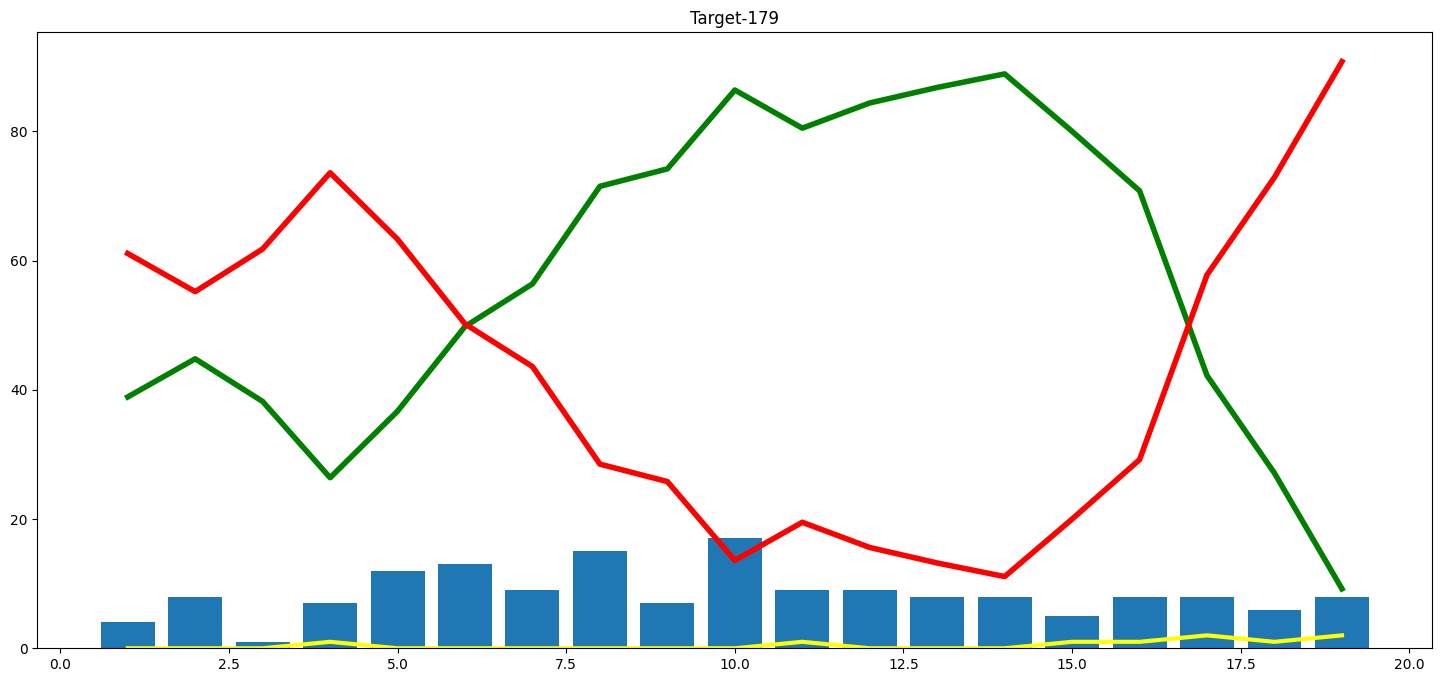

In [79]:
plt.figure(figsize=(18,8))
plt.plot(temp_df['end_of_over'],temp_df['wickets_in_over'],color='yellow',linewidth=3)
plt.plot(temp_df['end_of_over'],temp_df['win_probab_chasing_team'],color='green',linewidth=4)
plt.plot(temp_df['end_of_over'],temp_df['lose_probab_chasing_team'],color='red',linewidth=4)
plt.bar(temp_df['end_of_over'],temp_df['runs_after_over'])
plt.title('Target-' + str(target))

In [80]:
final_df.batting_team.unique()

array(['Delhi Capitals', 'Punjab Kings', 'Rajasthan Royals',
       'Kolkata Knight Riders', 'Chennai Super Kings',
       'Sunrisers Hyderabad', 'Mumbai Indians',
       'Royal Challengers Bangalore'], dtype=object)

In [81]:
delivery_df.city.unique()

array(['Hyderabad', 'Bangalore', 'Mumbai', 'Indore', 'Kolkata', 'Delhi',
       'Chandigarh', 'Jaipur', 'Chennai', 'Cape Town', 'Port Elizabeth',
       'Durban', 'Centurion', 'East London', 'Johannesburg', 'Kimberley',
       'Bloemfontein', 'Ahmedabad', 'Cuttack', 'Nagpur', 'Dharamsala',
       'Visakhapatnam', 'Pune', 'Raipur', 'Ranchi', 'Abu Dhabi',
       'Sharjah', nan], dtype=object)

In [82]:
import pickle
pickle.dump(pipe, open('pipe.pkl', 'wb'))